In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 윈도우 기준 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 확인
print("폰트 설정 완료!")

폰트 설정 완료!


In [2]:
from pathlib import Path
import pandas as pd

# 현재 작업 폴더 기준 (노트북이 있는 폴더)
DATA_PATH = Path("online_retail_II.xlsx")

df_2009 = pd.read_excel(DATA_PATH, sheet_name="Year 2009-2010")
df_2010 = pd.read_excel(DATA_PATH, sheet_name="Year 2010-2011")

print(df_2009.shape)
print(df_2009.head())

(525461, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [3]:
# 합친 후 바로 분리
df = pd.concat([df_2009, df_2010], ignore_index=True)

# 날짜 타입 변환
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Train/Test 분리
train = df[df['InvoiceDate'] < '2011-11-09']
test  = df[df['InvoiceDate'] >= '2011-11-09']

print(f"Train: {len(train):,}행")
print(f"Train 기간: {train['InvoiceDate'].min()} ~ {train['InvoiceDate'].max()}")
print(f"\nTest: {len(test):,}행")
print(f"Test 기간: {test['InvoiceDate'].min()} ~ {test['InvoiceDate'].max()}")

Train: 976,588행
Train 기간: 2009-12-01 07:45:00 ~ 2011-11-08 18:41:00

Test: 90,783행
Test 기간: 2011-11-09 08:11:00 ~ 2011-12-09 12:50:00


In [4]:
# 1. 합치기
df = pd.concat([df_2009, df_2010], ignore_index=True)
print(f"2009-2010 시트: {len(df_2009):,}행")
print(f"2010-2011 시트: {len(df_2010):,}행")
print(f"합친 후 전체: {len(df):,}행")

# 2. 날짜 범위 확인
print(f"\n날짜 범위:")
print(f"시작: {df['InvoiceDate'].min()}")
print(f"종료: {df['InvoiceDate'].max()}")

# 3. 결측치 확인
print(f"\n결측치:")
print(df.isnull().sum())

# 4. 중복행 확인
print(f"\n중복행: {df.duplicated().sum():,}개")

# 칼럼별 결측치 + 사분위수 함께 보기
desc = df.describe()
desc.loc['missing'] = df.isnull().sum()
print(desc)

2009-2010 시트: 525,461행
2010-2011 시트: 541,910행
합친 후 전체: 1,067,371행

날짜 범위:
시작: 2009-12-01 07:45:00
종료: 2011-12-09 12:50:00

결측치:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

중복행: 34,335개
             Quantity                    InvoiceDate         Price  \
count    1.067371e+06                        1067371  1.067371e+06   
mean     9.938898e+00  2011-01-02 21:13:55.394028544  4.649388e+00   
min     -8.099500e+04            2009-12-01 07:45:00 -5.359436e+04   
25%      1.000000e+00            2010-07-09 09:46:00  1.250000e+00   
50%      3.000000e+00            2010-12-07 15:28:00  2.100000e+00   
75%      1.000000e+01            2011-07-22 10:23:00  4.150000e+00   
max      8.099500e+04            2011-12-09 12:50:00  3.897000e+04   
std      1.727058e+02                            NaN  1.235531e+02   
missing  0.000000e+00                  

In [5]:
# 원본 train에서 Invoice가 C로 시작하는 모든 취소 거래만 추출합니다.
inv = train['Invoice'].astype(str)
c = train[inv.str.startswith('C')].copy()

# (1) 비상품 취소 — 애초에 매칭 대상 아님
prod = c['StockCode'].astype(str).str.match(r'^\d{5}[A-Za-z]*$')
print(f"비상품 취소: {(~prod).sum():,}")

# (2) Customer ID 결측 취소 — 매칭 불가
print(f"ID 결측 취소: {c['Customer ID'].isna().sum():,}")

# (3) 상품 + Customer ID가 있어 원주문 매칭을 시도할 수 있는 취소
real = c[prod & c['Customer ID'].notna()]
print(f"상품+ID 보유 취소: {len(real):,}")

비상품 취소: 1,151
ID 결측 취소: 728
상품+ID 보유 취소: 16,912


In [6]:
df_train = train.copy()

# 0. 완전 중복행 제거 (매칭 전에 해야 중복 취소로 이중 제거되는 걸 방지)
df_train = df_train.drop_duplicates()

inv = df_train['Invoice'].astype(str)
is_cancel = inv.str.startswith('C')

has_id = df_train['Customer ID'].notna()

cancels = df_train[is_cancel & has_id].copy()
orders  = df_train[~is_cancel & has_id].copy()
for d in (cancels, orders):
    d['qty_abs'] = d['Quantity'].abs()

orders = orders.sort_values('InvoiceDate')
grp = orders.groupby(['Customer ID', 'StockCode', 'qty_abs']).groups

remove_idx, matched = set(), 0
for _, c in cancels.iterrows():
    k = (c['Customer ID'], c['StockCode'], c['qty_abs'])
    if k not in grp:
        continue
    # 취소 시점 이전의 원주문만, 가장 가까운 1건만 제거
    cands = [i for i in grp[k]
             if i not in remove_idx and orders.at[i, 'InvoiceDate'] <= c['InvoiceDate']]
    if cands:
        remove_idx.add(cands[-1])
        matched += 1

print(f"취소 행: {len(cancels):,} | 매칭된 원주문: {matched:,} | 미매칭: {len(cancels)-matched:,}")

df_train = orders.drop(index=remove_idx).drop(columns='qty_abs')

# 2. 비상품 StockCode 제거
is_product = df_train['StockCode'].astype(str).str.match(r'^\d{5}[A-Za-z]*$')
print("제거 대상 코드:", sorted(df_train.loc[~is_product, 'StockCode'].astype(str).unique()))
df_train = df_train[is_product]

# 3. 잔여 이상치
df_train = df_train[(df_train['Quantity'] > 0) & (df_train['Price'] > 0)]
df_train['Sales'] = df_train['Quantity'] * df_train['Price']
print(f"최종 Train: {len(df_train):,}행 | 고객: {df_train['Customer ID'].nunique():,}명")

print("\n전처리 완료!")
print(f"최종 Train: {len(df_train):,}행")
print(f"고객 수: {df_train['Customer ID'].nunique():,}명")
print(df_train[['Invoice','Quantity','Price','Sales']].head())

취소 행: 17,323 | 매칭된 원주문: 6,001 | 미매칭: 11,322
제거 대상 코드: ['ADJUST', 'ADJUST2', 'BANK CHARGES', 'C2', 'D', 'DOT', 'M', 'PADS', 'POST', 'SP1002', 'TEST001', 'TEST002']
최종 Train: 705,853행 | 고객: 5,678명

전처리 완료!
최종 Train: 705,853행
고객 수: 5,678명
  Invoice  Quantity  Price  Sales
0  489434        12   6.95   83.4
1  489434        12   6.75   81.0
2  489434        12   6.75   81.0
3  489434        48   2.10  100.8
4  489434        24   1.25   30.0


In [7]:
import numpy as np

# 스냅샷 = Train 마지막 날 +1일
snapshot = df_train['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_train.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('Sales', 'sum')
).reset_index()

# Monetary 0 이하 방어
rfm = rfm[rfm['Monetary'] > 0]

In [8]:
print(rfm[['Recency','Frequency','Monetary']].skew())

Recency       0.809820
Frequency    11.267733
Monetary     27.084940
dtype: float64


In [9]:
from sklearn.preprocessing import StandardScaler

feature_names = ['Recency', 'Frequency', 'Monetary']

# 로그 변환 (0 방지용 log1p)
rfm_log = rfm[feature_names].apply(np.log1p)

# 표준화 (평균0, 분산1)
scaler = StandardScaler()
rfm_scaled = pd.DataFrame(
    scaler.fit_transform(rfm_log),
    columns=feature_names,
    index=rfm.index
)

# Customer ID는 스케일링 대상 아니므로 따로 붙임 (예시의 region_encoded 위치와 동일한 역할)
rfm_scaled['Customer ID'] = rfm['Customer ID']

print(rfm_scaled[feature_names].describe().round(2))
print(rfm_scaled[feature_names].skew())

print(rfm.nlargest(5, 'Monetary'))

       Recency  Frequency  Monetary
count  5678.00    5678.00   5678.00
mean      0.00      -0.00     -0.00
std       1.00       1.00      1.00
min      -2.53      -1.02     -3.93
25%      -0.72      -1.02     -0.71
50%       0.20      -0.15     -0.04
75%       0.90       0.55      0.66
max       1.34       5.40      4.74
Recency     -0.607684
Frequency    1.038695
Monetary     0.256691
dtype: float64
      Customer ID  Recency  Frequency   Monetary
5498      18102.0        5        141  567357.02
2193      14646.0        7        131  490894.82
1720      14156.0        2        139  292073.54
2441      14911.0        2        331  233792.78
4883      17450.0        6         40  213313.88


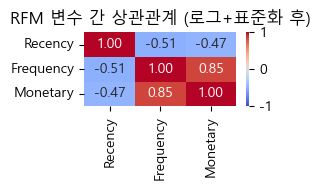

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(3,2))
sns.heatmap(
    rfm_scaled[feature_names].corr(),
    vmin=-1, vmax=1,          # 음의 상관 표시 필수
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0
)
plt.title('RFM 변수 간 상관관계 (로그+표준화 후)')
plt.tight_layout()
plt.show()

k=5 부근부터 완만한 감소 구간

k= 2 | inertia=   8472.6 | silhouette=0.4382
k= 3 | inertia=   6354.9 | silhouette=0.3491
k= 4 | inertia=   4774.7 | silhouette=0.3748
k= 5 | inertia=   4011.6 | silhouette=0.3402
k= 6 | inertia=   3485.1 | silhouette=0.3355
k= 7 | inertia=   3144.0 | silhouette=0.2930
k= 8 | inertia=   2840.6 | silhouette=0.2973
k= 9 | inertia=   2605.9 | silhouette=0.2957
k=10 | inertia=   2415.3 | silhouette=0.2854

Elbow 기준 k: 5
Silhouette 기준 k: 2
최종 선택 k: 5


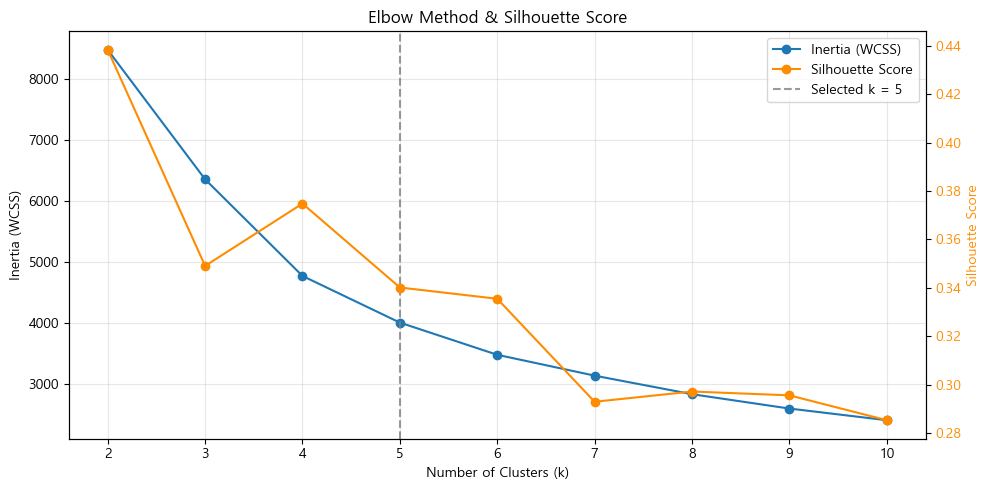

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

X = rfm_scaled[feature_names]
k_range = list(range(2, 11))

inertias = []
silhouettes = []

# =========================
# K별 평가
# =========================
for k in k_range:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X)

    inertias.append(km.inertia_)
    silhouettes.append(
        silhouette_score(X, labels)
    )

    print(
        f"k={k:2d} | "
        f"inertia={km.inertia_:9.1f} | "
        f"silhouette={silhouettes[-1]:.4f}"
    )

# =========================
# Elbow 기준
# =========================
knee = KneeLocator(
    k_range,
    inertias,
    curve='convex',
    direction='decreasing'
)

elbow_k = knee.elbow

# =========================
# Silhouette 기준
# =========================
silhouette_k = k_range[np.argmax(silhouettes)]

# =========================
# 최종 k 선택
# =========================
if elbow_k is not None:

    elbow_idx = k_range.index(elbow_k)

    max_sil = max(silhouettes)
    elbow_sil = silhouettes[elbow_idx]

    # Elbow 지점의 실루엣이 최대값의 70% 이상이면 채택
    if elbow_sil >= max_sil * 0.70:
        best_k = elbow_k
    else:
        best_k = silhouette_k

else:
    best_k = silhouette_k


print(f"\nElbow 기준 k: {elbow_k}")
print(f"Silhouette 기준 k: {silhouette_k}")
print(f"최종 선택 k: {best_k}")


# =========================
# 하나의 그래프에 표시
# =========================
fig, ax1 = plt.subplots(figsize=(10, 5))

# Elbow / Inertia
line1 = ax1.plot(
    k_range,
    inertias,
    'o-',
    label='Inertia (WCSS)'
)

ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_xticks(k_range)
ax1.grid(alpha=0.3)

# 오른쪽 y축 생성
ax2 = ax1.twinx()

# Silhouette - 주황색
line2 = ax2.plot(
    k_range,
    silhouettes,
    'o-',
    color='darkorange',
    label='Silhouette Score'
)

ax2.set_ylabel(
    'Silhouette Score',
    color='darkorange'
)

ax2.tick_params(
    axis='y',
    labelcolor='darkorange'
)

# 최종 선택 k 표시
ax1.axvline(
    best_k,
    linestyle='--',
    color='gray',
    alpha=0.8,
    label=f'Selected k = {best_k}'
)

# 범례 합치기
lines = line1 + line2
labels = [line.get_label() for line in lines]

selected_line = ax1.get_lines()[-1]
lines.append(selected_line)
labels.append(selected_line.get_label())

ax1.legend(
    lines,
    labels,
    loc='best'
)

plt.title('Elbow Method & Silhouette Score')
plt.tight_layout()
plt.show()

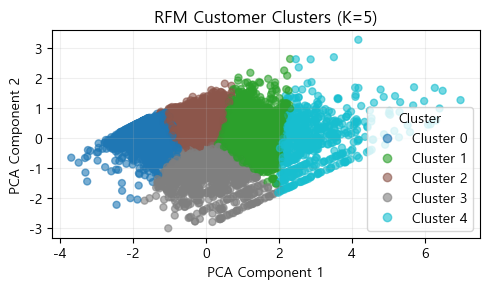

PCA 설명분산: [0.745 0.204]
누적 설명분산: 0.95


In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# =========================
# 1. 최적 k로 KMeans 학습
# =========================
kmeans = KMeans(
    n_clusters=best_k,   # 앞에서 선택된 best_k = 5
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X)

# RFM 데이터에 군집 번호 저장
rfm['cluster_5'] = labels


# =========================
# 2. PCA로 RFM 3차원 → 2차원 축소
# =========================
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)


# =========================
# 3. 산점도
# =========================
plt.figure(figsize=(5, 3))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    cmap='tab10',
    alpha=0.6,
    s=25
)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'RFM Customer Clusters (K={best_k})')

plt.legend(
    scatter.legend_elements()[0],
    [f'Cluster {i}' for i in range(best_k)],
    title='Cluster'
)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# PCA가 원래 RFM 정보를 얼마나 설명하는지
print(
    'PCA 설명분산:',
    pca.explained_variance_ratio_.round(3)
)

print(
    '누적 설명분산:',
    pca.explained_variance_ratio_.sum().round(3)
)

# PC1은 Frequency와 Monetary가 높고 Recency가 낮을수록 증가하므로, 고객의 종합적인 구매가치·활성도를 나타내는 축으로 해석

In [25]:
import pandas as pd

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=['PC1', 'PC2']
)

print(loadings)

                PC1       PC2
Recency   -0.488927  0.871233
Frequency  0.620916  0.312446
Monetary   0.612710  0.378590


In [12]:
for k in [4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    rfm[f'cluster_{k}'] = km.fit_predict(X)
    profile = rfm.groupby(f'cluster_{k}').agg(
        고객수=('Customer ID','count'),
        R=('Recency','mean'), F=('Frequency','mean'), M=('Monetary','mean')
    ).round(1)
    print(f"\n=== k={k} ===")
    print(profile.sort_values('M', ascending=False))


=== k=4 ===
            고객수      R     F        M
cluster_4                            
0          1038   29.9  19.2  10497.4
2          1520  206.7   5.2   1884.1
3          1097   25.6   2.7    784.3
1          2023  382.7   1.4    329.3

=== k=5 ===
            고객수      R     F        M
cluster_5                            
4           544   18.6  27.0  16087.0
1          1168   71.8   8.4   3324.3
2          1353  287.6   3.4   1152.3
3           997   26.1   2.4    694.1
0          1616  395.0   1.2    248.4


In [17]:
print(df_train.loc[df_train['Quantity'] > 20000, 
                   ['Invoice','StockCode','Quantity','InvoiceDate','Customer ID']])

Empty DataFrame
Columns: [Invoice, StockCode, Quantity, InvoiceDate, Customer ID]
Index: []


,Recency,Frequency,Monetary
cluster_5,,,
0,0.875,-0.908,-1.045
1,-0.425,0.842,0.850
2,0.658,-0.107,0.086
3,-1.026,-0.457,-0.335
4,-1.443,1.992,1.679


cluster_5
0    1616
1    1168
2    1353
3     997
4     544
Name: count, dtype: int64


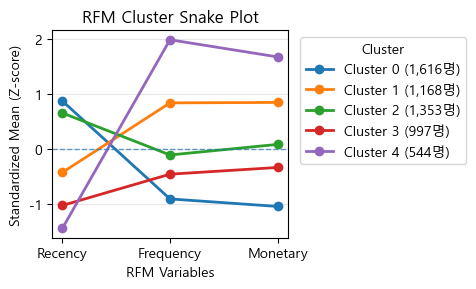

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. 표준화된 RFM 데이터에 Customer ID 추가
# ==========================================

snake_df = rfm_scaled[feature_names].copy()
snake_df['Customer ID'] = rfm['Customer ID'].values

# ==========================================
# 2. Customer ID 기준으로 cluster_5 병합
# ==========================================

snake_df = snake_df.merge(
    rfm[['Customer ID', 'cluster_5']],
    on='Customer ID',
    how='left',
    validate='one_to_one'
)

# 병합 이상 여부 확인
assert snake_df['cluster_5'].notna().all(), \
    "일부 Customer ID에 cluster가 매칭되지 않았습니다."

# ==========================================
# 3. 클러스터별 표준화 RFM 평균
# ==========================================

snake_mean = (
    snake_df
    .groupby('cluster_5')[feature_names]
    .mean()
)

display(snake_mean.round(3))


# ==========================================
# 4. 클러스터별 고객 수
# ==========================================

cluster_counts = (
    snake_df['cluster_5']
    .value_counts()
    .sort_index()
)

print(cluster_counts)


# ==========================================
# 5. Snake Plot
# ==========================================

plt.figure(figsize=(5, 3))

x = range(len(feature_names))

for cluster in snake_mean.index:

    values = snake_mean.loc[cluster, feature_names]
    n = cluster_counts.loc[cluster]

    plt.plot(
        x,
        values,
        marker='o',
        linewidth=2,
        label=f'Cluster {cluster} ({n:,}명)'
    )

# 표준화 평균 기준선
plt.axhline(
    0,
    linestyle='--',
    linewidth=1,
    alpha=0.7
)

plt.xticks(
    x,
    feature_names
)

plt.ylabel('Standardized Mean (Z-score)')
plt.xlabel('RFM Variables')
plt.title('RFM Cluster Snake Plot')

plt.legend(
    title='Cluster',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [28]:
cluster_name_map = {
    0: 'Lost',
    1: 'Loyal',
    2: 'At Risk',
    3: 'New / Promising',
    4: 'Champions'
}

rfm['Segment'] = rfm['cluster_5'].map(cluster_name_map)